In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/superstore_cleaned.csv')

print("Shape:", df.shape)
df.head()

Shape: (9977, 18)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Unit_Price,Profit_Margin,Revenue,Discount_Band,Price_Segment
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,130.9800,16.00,261.9600,No Discount,Premium
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,243.9800,30.00,731.9400,No Discount,Premium
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,7.3100,47.00,14.6200,No Discount,Premium
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,191.5155,-40.00,957.5775,High (41%+),Premium
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.1840,11.25,22.3680,Low (1-20%),Low


In [2]:
price_demand = df.groupby(['Category', 'Discount_Band']).agg(
    Avg_Unit_Price=('Unit_Price', 'mean'),
    Avg_Quantity=('Quantity', 'mean'),
    Avg_Profit_Margin=('Profit_Margin', 'mean'),
    Transaction_Count=('Sales', 'count')
).round(2).reset_index()

print(price_demand)

           Category    Discount_Band  Avg_Unit_Price  Avg_Quantity  \
0         Furniture      High (41%+)           41.88          3.78   
1         Furniture      Low (1-20%)          104.90          3.70   
2         Furniture  Medium (21-40%)          130.61          3.81   
3         Furniture      No Discount           75.74          3.86   
4   Office Supplies      High (41%+)           13.55          3.96   
5   Office Supplies      Low (1-20%)           30.24          3.76   
6   Office Supplies      No Discount           37.68          3.80   
7        Technology      High (41%+)          369.71          3.46   
8        Technology      Low (1-20%)          103.99          3.74   
9        Technology  Medium (21-40%)          147.47          3.72   
10       Technology      No Discount          122.09          3.79   

    Avg_Profit_Margin  Transaction_Count  
0              -72.87                218  
1                7.51                743  
2              -17.67         

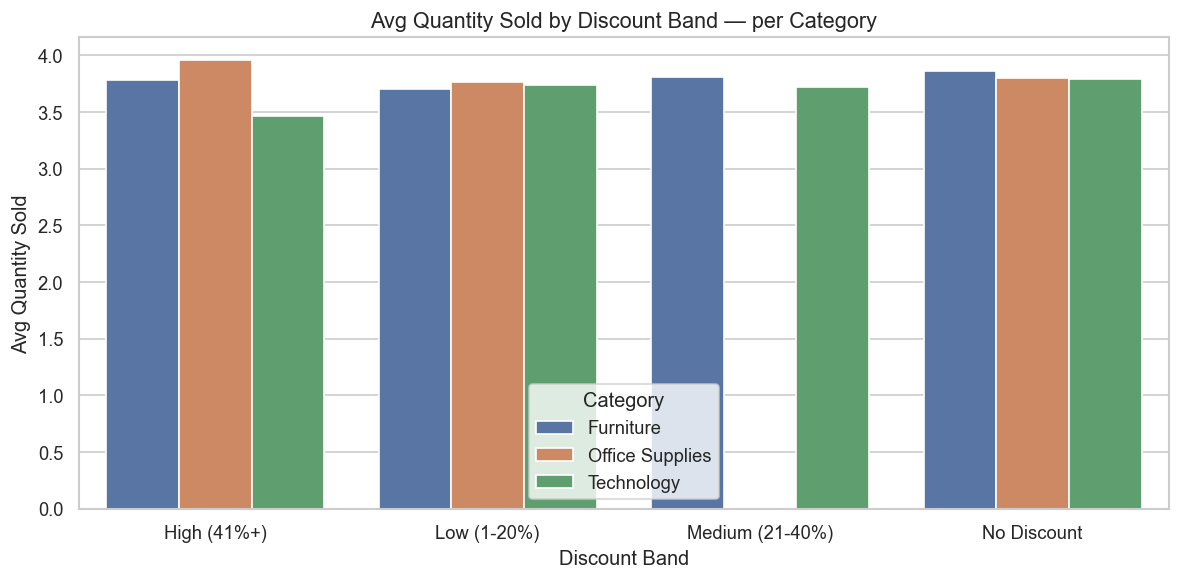

In [3]:
plt.figure(figsize=(10, 5))
sns.barplot(data=price_demand, x='Discount_Band', y='Avg_Quantity', hue='Category')
plt.title("Avg Quantity Sold by Discount Band — per Category", fontsize=13)
plt.xlabel("Discount Band")
plt.ylabel("Avg Quantity Sold")
plt.tight_layout()
plt.savefig('../outputs/10_quantity_by_discountband.png')
plt.show()

In [4]:
expected_bands = ['No Discount', 'Low (1-20%)', 'Medium (21-40%)', 'High (41%+)']

elasticity_base = df.groupby(['Sub-Category', 'Discount_Band']).agg(
    Avg_Price=('Unit_Price', 'mean'),
    Avg_Quantity=('Quantity', 'mean')
).reset_index()

elasticity_pivot = elasticity_base.pivot(
    index='Sub-Category',
    columns='Discount_Band',
    values=['Avg_Price', 'Avg_Quantity']
)

elasticity_pivot = elasticity_pivot.reindex(
    columns=pd.MultiIndex.from_product(
        [['Avg_Price', 'Avg_Quantity'], expected_bands]
    )
)

elasticity_pivot.columns = ['_'.join(col).strip() for col in elasticity_pivot.columns]
elasticity_pivot = elasticity_pivot.reset_index()

print("Pivot ready")
print(elasticity_pivot.columns.tolist())
elasticity_pivot.head()

Pivot ready
['Sub-Category', 'Avg_Price_No Discount', 'Avg_Price_Low (1-20%)', 'Avg_Price_Medium (21-40%)', 'Avg_Price_High (41%+)', 'Avg_Quantity_No Discount', 'Avg_Quantity_Low (1-20%)', 'Avg_Quantity_Medium (21-40%)', 'Avg_Quantity_High (41%+)']


,Sub-Category,Avg_Price_No Discount,Avg_Price_Low (1-20%),Avg_Price_Medium (21-40%),Avg_Price_High (41%+),Avg_Quantity_No Discount,Avg_Quantity_Low (1-20%),Avg_Quantity_Medium (21-40%),Avg_Quantity_High (41%+)
0,Accessories,63.987473,41.984500,NaN,NaN,3.895966,3.753289,NaN,NaN
1,Appliances,73.290701,58.048227,NaN,14.273761,3.767528,3.695312,NaN,3.507463
2,Art,9.276861,8.072644,NaN,NaN,3.822938,3.677852,NaN,NaN
3,Binders,70.228783,41.780691,NaN,13.469374,3.830861,3.886562,NaN,4.008170
4,Bookcases,142.006333,149.071827,126.414314,63.154121,3.516667,3.724490,4.0,4.363636


In [15]:
results = []

for _, row in elasticity_pivot.iterrows():
    sub_cat = row['Sub-Category']

    try:
        p1 = row['Avg_Price_No Discount']
        p2 = row['Avg_Price_Low (1-20%)']
        q1 = row['Avg_Quantity_No Discount']
        q2 = row['Avg_Quantity_Low (1-20%)']

        if pd.isna(p1) or pd.isna(q1):
            p1 = row['Avg_Price_Low (1-20%)']
            q1 = row['Avg_Quantity_Low (1-20%)']
            p2 = row['Avg_Price_Medium (21-40%)']
            q2 = row['Avg_Quantity_Medium (21-40%)']

        if pd.notna(p1) and pd.notna(p2) and pd.notna(q1) and pd.notna(q2) \
                and p1 != 0 and q1 != 0:
            pct_change_q = (q2 - q1) / q1
            pct_change_p = (p2 - p1) / p1
            elasticity = pct_change_q / pct_change_p if pct_change_p != 0 else np.nan
        else:
            elasticity = np.nan

    except Exception:
        elasticity = np.nan

    results.append({
        'Sub-Category': sub_cat,
        'Proxy_Elasticity': round(elasticity, 3) if pd.notna(elasticity) else np.nan
    })

elasticity_df = pd.DataFrame(results)
print(elasticity_df)

   Sub-Category  Proxy_Elasticity
0   Accessories             0.107
1    Appliances             0.092
2           Art             0.292
3       Binders            -0.036
4     Bookcases             1.188
5        Chairs             0.602
6       Copiers             0.268
7     Envelopes             0.087
8     Fasteners            -0.939
9   Furnishings             1.012
10       Labels             0.261
11     Machines             0.912
12        Paper            -0.037
13       Phones            -0.404
14      Storage             0.430
15     Supplies             0.104
16       Tables             0.249


In [42]:
def classify_response(e):
    if pd.isna(e):
        return 'Low Confidence'
    elif e < -0.5:
        return 'High Price Sensitivity'
    elif -0.5 <= e <= 0.5:
        return 'Moderate / Stable'
    else:
        return 'Unstable / Noisy Response'

elasticity_df['Demand_Response'] = elasticity_df['Proxy_Elasticity'].apply(classify_response)

print("Observed Demand Response Classification")
print(elasticity_df[['Sub-Category', 'Proxy_Elasticity',
                       'Demand_Response']].to_string(index=False))

Observed Demand Response Classification
Sub-Category  Proxy_Elasticity           Demand_Response
 Accessories             0.107         Moderate / Stable
  Appliances             0.092         Moderate / Stable
         Art             0.292         Moderate / Stable
     Binders            -0.036         Moderate / Stable
   Bookcases             1.188 Unstable / Noisy Response
      Chairs             0.602 Unstable / Noisy Response
     Copiers             0.268         Moderate / Stable
   Envelopes             0.087         Moderate / Stable
   Fasteners            -0.939    High Price Sensitivity
 Furnishings             1.012 Unstable / Noisy Response
      Labels             0.261         Moderate / Stable
    Machines             0.912 Unstable / Noisy Response
       Paper            -0.037         Moderate / Stable
      Phones            -0.404         Moderate / Stable
     Storage             0.430         Moderate / Stable
    Supplies             0.104         Moderate 

In [ ]:
if 'Transaction_Count' in elasticity_df.columns:
    elasticity_df = elasticity_df.drop(columns=['Transaction_Count'])

weights = df.groupby('Sub-Category').size().reset_index(name='Transaction_Count')

elasticity_df = elasticity_df.merge(weights, on='Sub-Category', how='left')

elasticity_df['Reliability'] = pd.cut(
    elasticity_df['Transaction_Count'],
    bins=[0, 50, 200, 99999],
    labels=['Low Reliability', 'Moderate Reliability', 'High Reliability']
)

print("Proxy Elasticity with Data Reliability")
print(elasticity_df[['Sub-Category', 'Proxy_Elasticity',
                       'Demand_Response', 'Transaction_Count',
                       'Reliability']].to_string(index=False))

Proxy Elasticity with Data Reliability
Sub-Category  Proxy_Elasticity          Demand_Response  Transaction_Count          Reliability
 Accessories             0.107    Unusual — Investigate                775     High Reliability
  Appliances             0.092    Unusual — Investigate                466     High Reliability
         Art             0.292    Unusual — Investigate                795     High Reliability
     Binders            -0.036 Inelastic — Price Stable               1522     High Reliability
   Bookcases             1.188    Unusual — Investigate                228     High Reliability
      Chairs             0.602    Unusual — Investigate                615     High Reliability
     Copiers             0.268    Unusual — Investigate                 68 Moderate Reliability
   Envelopes             0.087    Unusual — Investigate                254     High Reliability
   Fasteners            -0.939 Inelastic — Price Stable                217     High Reliability
 

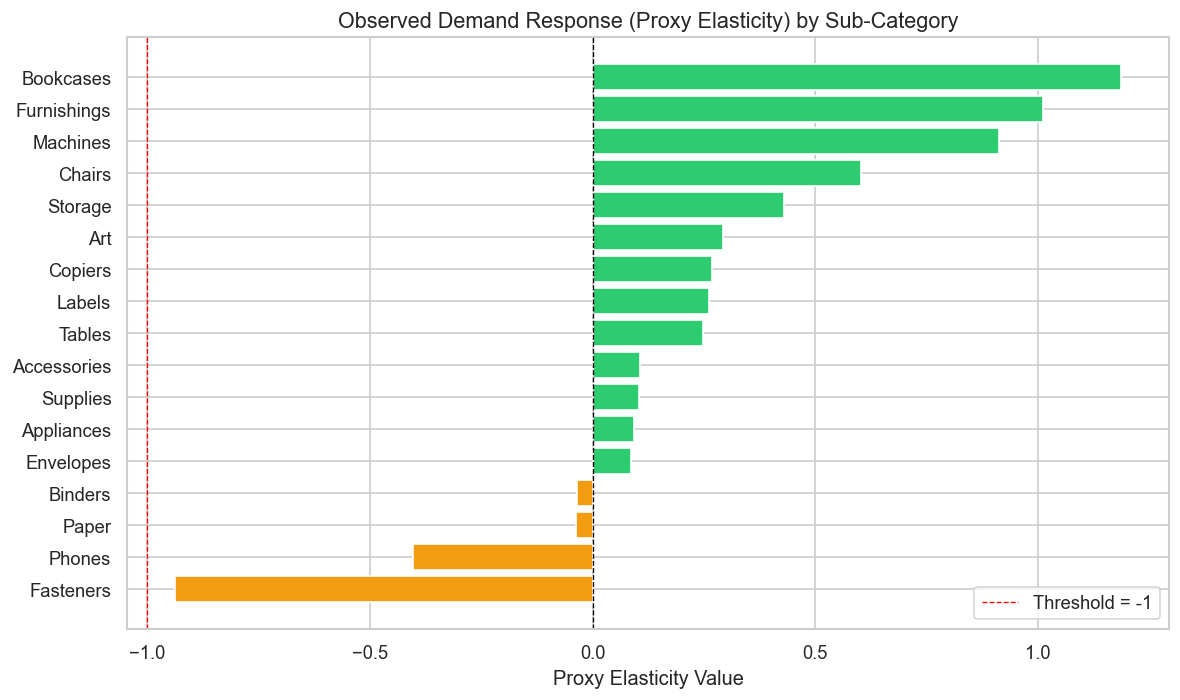

In [34]:
plot_df = elasticity_df.dropna(subset=['Proxy_Elasticity']).sort_values('Proxy_Elasticity')

colors = ['#e74c3c' if e < -1 else '#f39c12' if e < 0 else '#2ecc71'
          for e in plot_df['Proxy_Elasticity']]

plt.figure(figsize=(10, 6))
plt.barh(plot_df['Sub-Category'], plot_df['Proxy_Elasticity'], color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(-1, color='red', linestyle='--', linewidth=0.8, label='Threshold = -1')
plt.title("Observed Demand Response (Proxy Elasticity) by Sub-Category", fontsize=13)
plt.xlabel("Proxy Elasticity Value")
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/11_proxy_elasticity_by_subcategory.png')
plt.show()

In [35]:
cat_map = df[['Sub-Category', 'Category']].drop_duplicates()
elasticity_df = elasticity_df.merge(cat_map, on='Sub-Category', how='left')

cat_elasticity = elasticity_df.groupby('Category')['Proxy_Elasticity'].mean().round(3)
print("Avg Proxy Elasticity by Category")
print(cat_elasticity)

Avg Proxy Elasticity by Category
Category
Furniture          0.763
Office Supplies    0.028
Technology         0.221
Name: Proxy_Elasticity, dtype: float64


In [37]:
if 'Market_Benchmark_Price' in df.columns:
    df = df.drop(columns=['Market_Benchmark_Price'])
if 'Price_vs_Market' in df.columns:
    df = df.drop(columns=['Price_vs_Market'])

benchmark = df.groupby('Sub-Category')['Unit_Price'].median().reset_index()
benchmark.columns = ['Sub-Category', 'Market_Benchmark_Price']

df = df.merge(benchmark, on='Sub-Category', how='left')

df['Price_vs_Market'] = np.where(
    df['Unit_Price'] > df['Market_Benchmark_Price'] * 1.25, 'Overpriced',
    np.where(
        df['Unit_Price'] < df['Market_Benchmark_Price'] * 0.75, 'Underpriced', 'Fair'
    )
)

print("Price vs Market Benchmark Distribution")
print(df['Price_vs_Market'].value_counts())

Price vs Market Benchmark Distribution
Price_vs_Market
Overpriced     4091
Underpriced    3427
Fair           2459
Name: count, dtype: int64


In [38]:
price_perf = df.groupby('Price_vs_Market').agg(
    Avg_Profit_Margin=('Profit_Margin', 'mean'),
    Avg_Quantity=('Quantity', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Transaction_Count=('Sales', 'count')
).round(2)

print("Performance by Market Benchmark Position")
print(price_perf)

Performance by Market Benchmark Position
                 Avg_Profit_Margin  Avg_Quantity  Total_Profit  \
Price_vs_Market                                                  
Fair                         21.36          3.81      24007.61   
Overpriced                   19.17          3.81     263201.78   
Underpriced                  -3.25          3.76       -967.96   

                 Transaction_Count  
Price_vs_Market                     
Fair                          2459  
Overpriced                    4091  
Underpriced                   3427  


In [39]:
elasticity_df.to_csv('../outputs/elasticity_by_subcategory.csv', index=False)
df.to_csv('../data/superstore_cleaned.csv', index=False)

print("Elasticity results saved to outputs/")
print("Cleaned data updated with benchmark columns")

Elasticity results saved to outputs/
Cleaned data updated with benchmark columns


In [43]:

print("PRICING RESPONSE ANALYSIS — SUMMARY")


high_sens = elasticity_df[elasticity_df['Demand_Response'] == 'High Price Sensitivity']
moderate  = elasticity_df[elasticity_df['Demand_Response'] == 'Moderate / Stable']
noisy     = elasticity_df[elasticity_df['Demand_Response'] == 'Unstable / Noisy Response']
low_conf  = elasticity_df[elasticity_df['Demand_Response'] == 'Low Confidence']

print(f"\nHigh Price Sensitivity     : {len(high_sens)}")
print(high_sens['Sub-Category'].tolist())

print(f"\nModerate / Stable          : {len(moderate)}")
print(moderate['Sub-Category'].tolist())

print(f"\nUnstable / Noisy Response  : {len(noisy)}")
print(noisy['Sub-Category'].tolist())

print(f"\nLow Confidence             : {len(low_conf)}")
print(low_conf['Sub-Category'].tolist())

print(f"\nCategory Avg Proxy Elasticity:")
print(cat_elasticity)

print("\nMethodology Note:")
print("Due to lack of controlled price variation, traditional elasticity")
print("thresholds were not directly applicable. Observed demand response")
print("was categorized into sensitivity bands for directional insights only.")

PRICING RESPONSE ANALYSIS — SUMMARY

High Price Sensitivity     : 1
['Fasteners']

Moderate / Stable          : 12
['Accessories', 'Appliances', 'Art', 'Binders', 'Copiers', 'Envelopes', 'Labels', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']

Unstable / Noisy Response  : 4
['Bookcases', 'Chairs', 'Furnishings', 'Machines']

Low Confidence             : 0
[]

Category Avg Proxy Elasticity:
Category
Furniture          0.763
Office Supplies    0.028
Technology         0.221
Name: Proxy_Elasticity, dtype: float64

Methodology Note:
Due to lack of controlled price variation, traditional elasticity
thresholds were not directly applicable. Observed demand response
was categorized into sensitivity bands for directional insights only.


Pricing Response Analysis — Conclusions

Methodology Note
Due to the lack of controlled price variation in this dataset, traditional
elasticity thresholds were not directly applicable. Instead, observed demand
response was categorized into sensitivity bands to provide directional insights
for pricing strategy.

What the Results Show

Moderate / Stable sub-categories:
Demand shows limited response to price changes.
These products can support reduced discounting or modest price increases
with relatively low demand risk.

Unstable / Noisy Response sub-categories:
Mixed demand patterns likely reflect product heterogeneity, regional variation,
or inconsistent discount behavior — not true price sensitivity.
Strong pricing recommendations should not be made for these without better data.

High Price Sensitivity sub-categories:
Demand responds meaningfully to price changes.
Discounting may increase volume here — but only if volume gain offsets margin loss.

Key Findings
- Some categories show moderate response to price changes
- Many sub-categories show unstable demand patterns due to mixed pricing behavior
- Discounting does not consistently increase demand across the board
- Pricing impact varies significantly across product types
- Loss-making sub-categories from EDA (Tables, Bookcases, Supplies) remain
  the strongest candidates for pricing correction regardless of elasticity band

Business Implication
Pricing strategy cannot be uniform.
Moderate/Stable products → reduce discounts, test small price increases
Unstable products → fix base pricing issues before applying discount strategies
Loss-making products → immediate pricing correction needed

Next Step
These sensitivity bands feed into Step 4 Scenario Simulation — where we model
revenue and profit impact of specific price changes per category,
focusing on where decisions are most defensible.